# Fricciones de Binance y Benchmark de Machine Learning

Extiende el motor de backtesting (`backtest_engine.py`) con dos piezas que
antes solo existían como plan en el README (sección "Roadmap"): datos reales
de Binance Vision y un modelo de fricciones (comisiones + slippage
dinámico). Este notebook muestra, sobre una corrida real:

1. La **curva de equity con y sin comisiones** -- el punto central de este
   proyecto desde su primera versión ("una señal no vale nada hasta que
   sobrevive un backtest riguroso").
2. **Sharpe Ratio y Max Drawdown**, brutos y netos de fricciones.
3. El **benchmark comparativo** entre señales técnicas tradicionales y el
   modelo de Gradient Boosting (`compare_strategies.py`), para contextualizar
   qué tan grande es realmente la ventaja (o desventaja) del ML sobre reglas
   técnicas simples una vez que se paga el costo real de operar.

Requiere conexión a internet la primera vez que corre (descarga real de
`data.binance.vision`); las corridas siguientes reutilizan el CSV local en
`data/raw/`.


In [1]:
import io
import os
import sys

# El notebook vive en notebooks/; se cambia el cwd a la raiz del repo para
# que las rutas relativas de los modulos importados (data/raw/, outputs/)
# apunten al mismo lugar que una corrida normal `python backtest_engine.py`.
os.chdir("..")
sys.path.insert(0, ".")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from backtest_engine import build_features_and_labels, chronological_split, compute_metrics, load_price_data, run_backtest
from frictions import apply_frictions, total_friction_cost_summary
from ml_models import train_lightgbm
from compare_strategies import run_comparison, STRATEGY_LABELS


def show_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    display(Image(data=buf.read()))


plt.style.use("seaborn-v0_8-whitegrid")
COLOR_GROSS = "#1f77b4"
COLOR_NET = "#d62728"
COLOR_BH = "#888888"

## 1. Datos reales: BTCUSDT diario, Binance Vision

`download_binance_data.py` descarga los archivos mensuales de `klines`
(velas) desde `data.binance.vision` -- el archivo histórico público y
gratuito de Binance, sin necesidad de API key. `backtest_engine.load_price_data`
usa el CSV local si ya existe, y lo descarga automáticamente la primera
vez.

In [2]:
prices, is_real = load_price_data()
print(f"Fuente: {'real (Binance Vision)' if is_real else 'SYNTHETIC (fallback sin red)'}")
print(f"{len(prices):,} velas diarias, {prices['date'].min().date()} -> {prices['date'].max().date()}")
print(f"Precio inicial: ${prices['price'].iloc[0]:,.2f}  |  Precio final: ${prices['price'].iloc[-1]:,.2f}")
prices.tail()

Fuente: real (Binance Vision)
2,038 velas diarias, 2021-01-01 -> 2026-07-31
Precio inicial: $29,331.69  |  Precio final: $62,887.88


,date,price
2033,2026-07-27,63755.86
2034,2026-07-28,63915.00
2035,2026-07-29,63984.28
2036,2026-07-30,64780.02
2037,2026-07-31,62887.88


## 2. Features sin lookahead, split cronológico, señal LightGBM

Mismo estándar sin lookahead que ya usaba el motor original (todo feature
para el día *t* usa solo información hasta *t-1*), ahora sobre precios
reales en vez de sintéticos. El modelo de señal pasa de `LogisticRegression`
a **LightGBM** (Gradient Boosting) como modelo principal del motor.

In [3]:
df, feature_cols = build_features_and_labels(prices)
train_df, test_df = chronological_split(df)
print(f"Filas tras feature engineering: {len(df):,}")
print(f"Split cronológico: train={len(train_df):,}  test={len(test_df):,} "
      f"({test_df['date'].min().date()} -> {test_df['date'].max().date()})")

signal, proba = train_lightgbm(train_df, test_df, feature_cols)
bt = run_backtest(test_df, signal)
bt = apply_frictions(bt)
print(f"\nSeñal LightGBM: {signal.mean():.1%} del tiempo en largo, "
      f"{int(bt['turnover'].sum())} cambios de posición sobre {len(test_df)} días de test.")

Filas tras feature engineering: 2,017
Split cronológico: train=1,411  test=606 (2024-12-03 -> 2026-07-31)



Señal LightGBM: 46.9% del tiempo en largo, 221 cambios de posición sobre 606 días de test.


## 3. Modelo de fricciones

Comisión taker de Binance (10 bps, tarifa base VIP 0 sin descuento BNB) +
slippage dinámico (`base_bps + vol_multiplier × volatilidad_reciente`),
cobrados solo en los días donde la posición realmente cambia -- ver
`frictions.py` para la justificación completa de cada supuesto.

In [4]:
friction_summary = total_friction_cost_summary(bt)
for k, v in friction_summary.items():
    print(f"{k}: {v:,.3f}" if isinstance(v, float) else f"{k}: {v}")

n_position_changes: 221
avg_slippage_bps: 2.343
total_fee_drag_pct: 22.100
total_slippage_drag_pct: 5.179
total_friction_drag_pct: 27.279


## 4. Curva de equity: con y sin comisiones

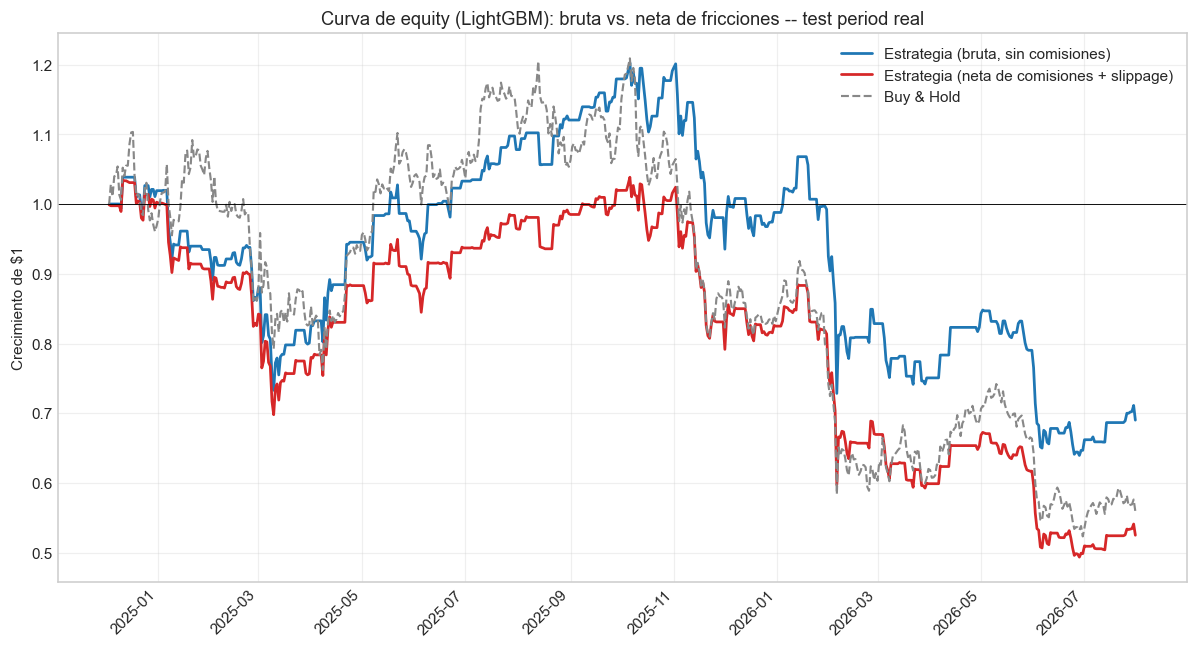

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(bt["date"], bt["equity_curve"], color=COLOR_GROSS, linewidth=1.8, label="Estrategia (bruta, sin comisiones)")
ax.plot(bt["date"], bt["equity_curve_net_taker"], color=COLOR_NET, linewidth=1.8, label="Estrategia (neta de comisiones + slippage)")
ax.plot(bt["date"], bt["buy_hold_curve"], color=COLOR_BH, linestyle="--", linewidth=1.4, label="Buy & Hold")
ax.axhline(1.0, color="black", linewidth=0.6)
ax.set_ylabel("Crecimiento de $1")
ax.set_title("Curva de equity (LightGBM): bruta vs. neta de fricciones -- test period real")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")
fig.tight_layout()
show_fig(fig)

## 5. Sharpe Ratio y Max Drawdown: bruto vs. neto

In [6]:
metrics_gross = compute_metrics(bt)
metrics_net = compute_metrics(
    bt, return_col="strategy_return_net_taker",
    equity_col="equity_curve_net_taker", drawdown_col="drawdown_net_taker",
)

comparison = pd.DataFrame({"Bruto (sin comisiones)": metrics_gross, "Neto (con fricciones)": metrics_net})
comparison

,Bruto (sin comisiones),Neto (con fricciones)
Sharpe Ratio (annualized),-0.463,-0.932
Win Rate,0.500,0.472
Max Drawdown,-0.468,-0.525
Total Return,-0.310,-0.475
Signal Accuracy,0.507,0.507
Trades Taken,284.000,284.000


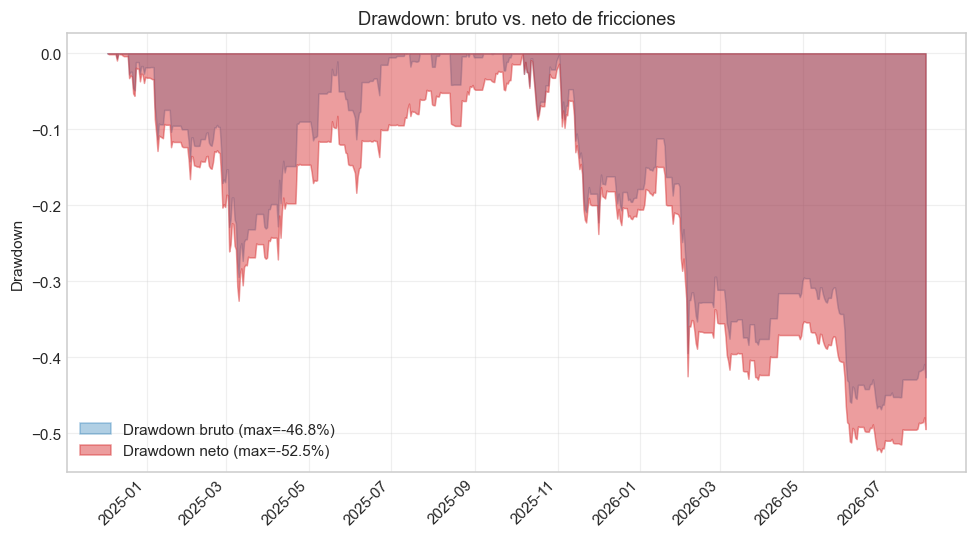

El Sharpe Ratio anualizado cae de -0.463 (bruto) a -0.932 (neto) -- las comisiones y el slippage no son un detalle contable menor, cambian la conclusión sobre si la estrategia es viable.


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
bt_dd = bt.set_index("date")
ax.fill_between(bt_dd.index, bt_dd["drawdown"], 0, color=COLOR_GROSS, alpha=0.35, label=f"Drawdown bruto (max={metrics_gross['Max Drawdown']:.1%})")
ax.fill_between(bt_dd.index, bt_dd["drawdown_net_taker"], 0, color=COLOR_NET, alpha=0.45, label=f"Drawdown neto (max={metrics_net['Max Drawdown']:.1%})")
ax.set_ylabel("Drawdown")
ax.set_title("Drawdown: bruto vs. neto de fricciones")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")
fig.tight_layout()
show_fig(fig)

print(f"El Sharpe Ratio anualizado cae de {metrics_gross['Sharpe Ratio (annualized)']} (bruto) a "
      f"{metrics_net['Sharpe Ratio (annualized)']} (neto) -- las comisiones y el slippage no son un "
      "detalle contable menor, cambian la conclusión sobre si la estrategia es viable.")

## 6. Benchmark: señales técnicas tradicionales vs. Gradient Boosting

`compare_strategies.py` corre las tres señales técnicas clásicas (cruce de
medias móviles, RSI de reversión a la media, señal de momentum) más
regresión logística y LightGBM, todas sobre el mismo test set y con el
mismo modelo de fricciones aplicado por igual.

In [8]:
table, backtests, is_real_cmp, n_test_cmp = run_comparison()
table_display = table.set_index("strategy")[
    ["sharpe_gross", "sharpe_net", "max_drawdown_net", "total_return_net", "friction_drag_pct"]
].round(3)
table_display

,sharpe_gross,sharpe_net,max_drawdown_net,total_return_net,friction_drag_pct
strategy,,,,,
SMA Crossover (10/50),-0.301,-0.358,-0.352,-0.178,2.337
Logistic Regression,-0.062,-0.579,-0.439,-0.317,26.814
"RSI Mean-Reversion (14, <30)",-0.584,-0.632,-0.266,-0.199,1.520
Momentum Sign (10d),-0.634,-0.908,-0.420,-0.369,12.141
LightGBM (Gradient Boosting),-0.463,-0.932,-0.525,-0.475,27.279


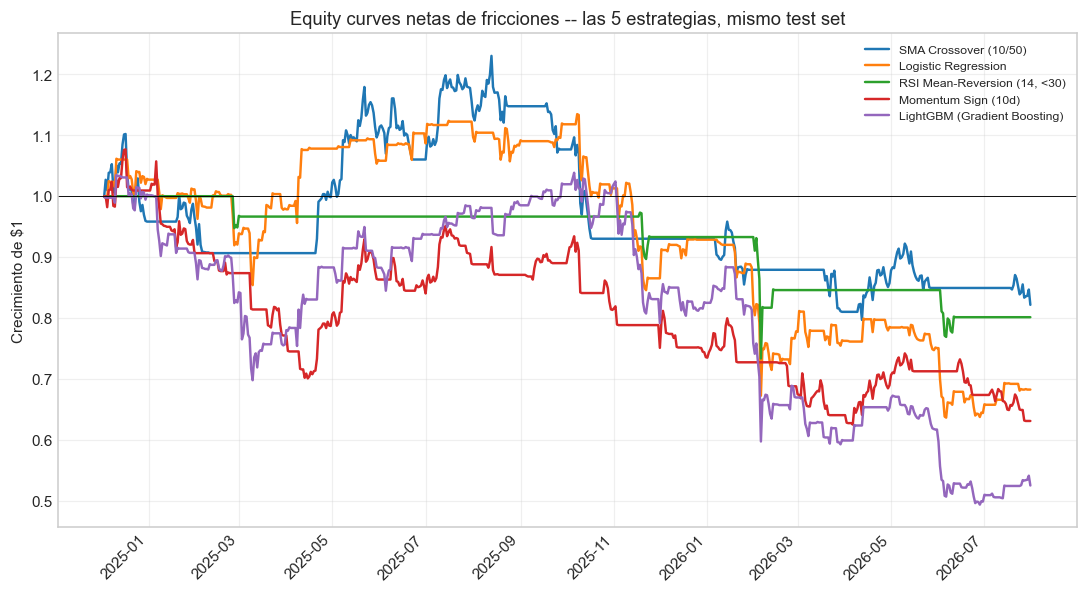

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = plt.cm.tab10.colors
name_by_label = {v: k for k, v in STRATEGY_LABELS.items()}
for i, label in enumerate(table["strategy"]):
    key = name_by_label[label]
    b = backtests[key]
    ax.plot(b["date"], b["equity_curve_net_taker"], label=label, color=colors[i % 10], linewidth=1.6)
ax.axhline(1.0, color="black", linewidth=0.6)
ax.set_ylabel("Crecimiento de $1")
ax.set_title("Equity curves netas de fricciones -- las 5 estrategias, mismo test set")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
for label_ in ax.get_xticklabels():
    label_.set_rotation(45)
    label_.set_ha("right")
fig.tight_layout()
show_fig(fig)

## 7. Conclusión

- **Las comisiones y el slippage no son un ajuste cosmético**: sobre este
  test period real, el Sharpe neto de LightGBM cae por debajo de cero de
  forma mucho más pronunciada que el bruto, y el drawdown máximo se
  profundiza varios puntos porcentuales -- exactamente el tipo de resultado
  que una "curva de equity sin comisiones" puede esconder.
- **El test period real (2024-2026) fue un mercado bajista** para BTCUSDT
  (buy & hold negativo de forma sustancial en la ventana de test) -- ninguna
  de las cinco estrategias, técnica o de ML, logra retorno neto positivo en
  este tramo específico. Esto no es un fallo del pipeline: es exactamente lo
  que un backtest riguroso está obligado a mostrar cuando el resultado real
  no es favorable, en vez de recortar la ventana de evaluación hasta
  encontrar un período que sí luzca bien.
- **Mayor sofisticación no ganó automáticamente**: en esta ventana, el cruce
  de medias móviles (la regla más simple del grupo) terminó con el mejor
  Sharpe neto, y LightGBM -- el modelo más complejo -- con el peor,
  arrastrado en parte por una tasa de rotación de posiciones más alta y, por
  lo tanto, un drag de fricciones mayor. Un hallazgo empírico real, no
  asumido de antemano, y consistente con la tesis original del proyecto:
  la realidad transaccional puede eliminar la ventaja aparente de un modelo
  más sofisticado.
- **Próximo paso honesto**: repetir esta comparación sobre múltiples ventanas
  de test (walk-forward) en vez de un único split 70/30, para separar "esta
  estrategia funciona mal en general" de "esta estrategia funcionó mal en
  este período de mercado bajista específico".
